In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
df = pd.read_csv('ghrelin_update.csv')
standard = pd.read_csv('standard.csv')
df = df[df.validation == 'valid']

In [3]:
df

,id,state,Ghrelin (Peak area/IS),validation
0,33.2g,Agg-,3.930149,valid
1,6561.1c,Agg-,4.765242,valid
2,76.4b,Agg-,5.948048,valid
4,Agg-,Agg-,9.402319,valid
5,640.3 1h,Agg+,5.227442,valid
6,6561.1e,Agg+,4.810683,valid
7,33.2f,Agg+,4.873890,valid
8,6561.1g,Agg+,5.197444,valid
9,80.41,Agg+,3.231129,valid
10,NaN,Control,2.356875,valid


In [5]:
# one-way ANOVA
response_var = 'Ghrelin (Peak area/IS)'
formula = f'Q("{response_var}") ~ state'
model  = ols(formula, data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df[response_var], groups=df['state'], alpha=0.05)
tukey_summary = tukey.summary()
print(tukey_summary)



 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
  Agg+    Agg-   1.3433 0.3906 -1.3122  3.9988  False
  Agg+ Control  -3.9606 0.0034 -6.4642  -1.457   True
  Agg- Control  -5.3039 0.0006 -7.9594 -2.6485   True
-----------------------------------------------------


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_60800/1691493350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.stripplot(x='state', y='Ghrelin (Peak area/IS)', data = df, order = ['Control', 'Agg+', 'Agg-'], jitter=True, dodge=False,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_60800/1691493350.py:5: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  g = sns.stripplot(x='state', y='Ghrelin (Peak area/IS)', data = df, order = ['Control', 'Agg+', 'Agg-'], jitter=True, dodge=False,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_60800/1691493350.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


[Text(0, 0, 'ctrl'), Text(1, 0, 'Agg$^{+}$'), Text(2, 0, 'Agg$^{-}$')]

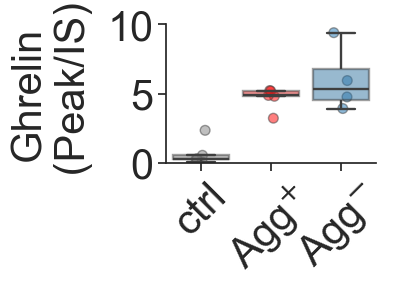

In [7]:
sns.set(font_scale=2.7) 
sns.set_style("ticks")
plt.subplots(figsize= (2.7,1.8)) #2.7,4

g = sns.stripplot(x='state', y='Ghrelin (Peak area/IS)', data = df, order = ['Control', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
              marker='o', size=7, linewidth=1, edgecolor='gray', palette=['gray', 'red','Tab:blue'], alpha=0.5, zorder=1)
g = sns.boxplot(x = 'state', y = 'Ghrelin (Peak area/IS)', data = df, order = ['Control', 'Agg+', 'Agg-'],
                palette=['gray', 'red','Tab:blue'], linewidth=1.7, showfliers=False, boxprops=dict(alpha=.5))

plt.ylim(0, 10)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(trim=False, bottom=False)
# g.tick_params(bottom=False)
plt.xlabel(None)
g.set_ylabel('Ghrelin\n (Peak/IS)',labelpad=10, fontsize=30)

g.set_xticklabels( ('ctrl', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/ghrelin.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

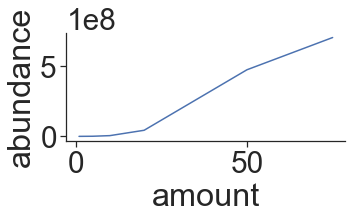

In [8]:
plt.subplots(figsize= (5,2))
sns.lineplot(x = 'amount', y = 'abundance', data = standard[standard.condition == 'third'])
sns.despine()

In [9]:
standard

,amount,abundance,condition
0,1,1.238651e+06,second
1,5,2.462740e+08,second
2,10,4.753812e+08,second
3,20,7.043907e+08,second
4,50,1.249565e+09,second
5,75,1.576144e+09,second
6,1,1.959153e+05,third
7,5,9.560986e+05,third
8,10,5.382066e+06,third
9,20,4.362585e+07,third
